In [ ]:
# ----------------------------
# Install required packages
# ----------------------------

In [ ]:
!pip install tensorflow==2.12.0 scikit-learn geopandas matplotlib seaborn pandas

ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0)
ERROR: No matching distribution found for tensorflow==2.12.0


In [ ]:
!pip install geopandas rasterio rioxarray xarray scikit-learn shapely scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.4 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import rioxarray as rxr
import xarray as xr
import matplotlib.pyplot as plt
import scipy.ndimage as ndi

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
!pip install rasterio

import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from tqdm import tqdm
import geopandas as gpd
import numpy as np
from libpysal.weights import KNN
from esda.moran import Moran
import matplotlib.pyplot as plt
import mapclassify as mc
import pandas as pd
from scipy.stats import theilslopes
from shapely.geometry import Point
import numpy as np
import pandas as pd
import geopandas as gpd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, Concatenate
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from tensorflow.keras.layers import RNN, SimpleRNNCell
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Flatten
from sklearn.metrics import roc_curve, auc
import rioxarray as rxr
import xarray as xr
import numpy as np
import pandas as pd
from scipy import ndimage as ndi

In [ ]:
from google.colab import drive

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# ----------------------------
# Path to your stacked NDWI raster (time, y, x)
# The stack should contain NDWI for multiple years/seasons
# ----------------------------
ndwi_stack_path = "/content/drive/MyDrive/NDWI_2010_2020_stack.tif"

# Load the stacked raster
# The stack should be organized as [time, y, x] or [band, y, x]
ndwi_ds = rxr.open_rasterio(ndwi_stack_path, masked=True)
ndwi_ds = ndwi_ds.squeeze()  # remove extra dimensions if any



# ----------------------------
# Compute median NDWI and standard deviation (uncertainty)
# ----------------------------
median_ndwi = ndwi_ds.median(dim="band")  # or 'time' if time dim exists
std_ndwi = ndwi_ds.std(dim="band")

# ----------------------------
# Generate water mask (NDWI > 0.3)
# ----------------------------
water_mask = median_ndwi > 0.3

# ----------------------------
# Pixel area
# Adjust according to your dataset resolution
# ----------------------------
pixel_area = 30 * 30  # in m²

# ----------------------------
# Label connected water bodies
# ----------------------------
labeled_array, num_features = ndi.label(water_mask)

# ----------------------------
# Extract lake statistics
# ----------------------------
lake_records = []

for lake_id in range(1, num_features + 1):
    mask = labeled_array == lake_id
    area_m2 = mask.sum() * pixel_area

    # Minimal lake area threshold: 0.002 km² = 2000 m²
    if area_m2 >= 2000:
        lake_records.append({
            "lake_id": lake_id,
            "area_km2": area_m2 / 1e6,
            "uncertainty": float(std_ndwi.where(mask).mean())
        })

lake_df = pd.DataFrame(lake_records)
print(lake_df.head())

# ----------------------------
# Optional: Save lake statistics to CSV
# ----------------------------
lake_df.to_csv("/content/drive/MyDrive/lake_statistics_2010_2020.csv", index=False)

In [ ]:
# ----------------------------
# Merge lake attributes from CSV
# ----------------------------
lake_attributes = pd.read_csv("/content/updated_glacier_lakes_with_attributes.csv")  # Update path
lake_df = lake_df.merge(
    lake_attributes[['Lake_ID', 'Lake_Volume_m3', 'Proximity_to_Glacier_km', 'Watershed_Area_km2', 'Slope_deg']],
    left_on='lake_id', right_on='Lake_ID', how='left'
)


In [ ]:

# Rename columns to match thresholds
lake_df.rename(columns={
    "Lake_Volume_m3": "volume",
    "Proximity_to_Glacier_km": "glacier_distance",
    "Watershed_Area_km2": "watershed_area",
    "Slope_deg": "slope"
}, inplace=True)

# Ensure numeric and fill missing
for col in ["volume", "glacier_distance", "watershed_area", "slope"]:
    lake_df[col] = pd.to_numeric(lake_df[col], errors='coerce').fillna(0)


In [ ]:
# ----------------------------
# Bayesian posterior probability scoring
# ----------------------------
thresholds = {
    "area_km2": 0.05,
    "volume": 1.0,
    "glacier_distance": 500,
    "slope": 15
}

weights = {
    "area_km2": 0.35,
    "volume": 0.30,
    "glacier_distance": 0.20,
    "slope": 0.15
}

# Normalize weights
total_weight = sum(weights.values())
weights = {k: v / total_weight for k, v in weights.items()}

def compute_posterior(row):
    score = 0

    for feature in thresholds:
        if feature == "glacier_distance":
            condition = row[feature] < thresholds[feature]
        else:
            condition = row[feature] > thresholds[feature]

        score += weights[feature] * int(condition)

    return score

lake_df["posterior_prob"] = lake_df.apply(compute_posterior, axis=1)

In [ ]:
features = ["area_km2", "volume", "glacier_distance", "watershed_area", "slope"]

X = lake_df[features]
y = lake_df["bayesian_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
lake_df["susceptibility_class"] = pd.cut(
    lake_df["posterior_prob"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

In [ ]:
class_counts = lake_df["susceptibility_class"].value_counts().sort_index()

plt.figure(figsize=(8,5))
class_counts.plot(kind="bar")
plt.title("Susceptibility Class Distribution (2010–2020)")
plt.xlabel("Susceptibility Class")
plt.ylabel("Number of Lakes")
plt.xticks(rotation=45)


In [ ]:
historical = pd.read_csv("/content/drive/MyDrive/data/historical_glof.csv")

X_hist = historical[features]
y_hist = historical["glof_occurred"]

y_hist_pred = model.predict(X_hist)

In [ ]:
data = pd.read_csv('/content/updated_glacier_lakes_with_attributes.csv')

In [ ]:
# ----------------------------
# Static features (terrain, geomorphology)
static_cols = [
    'Slope_deg', 'Topographic_Potential', 'Dam_Slope',
    'Upstream_Watershed_Area_km2', 'Upstream_Glacier_Area_km2',
    'Upstream_Glacier_Volume_m3', 'Propagation_Probability_Index',
    'Index_of_Connectivity'
]


In [ ]:
# Temporal features (multi-year lake metrics)
temporal_cols = ['Lake_Area_km2', 'Lake_Volume_m3', 'Glacial_Lake_Area_km2', 'Glacial_Lake_Volume_m3', 'Proximity_to_Glacier_km']

In [ ]:
# Target: use Bayesian-based susceptibility score (continuous probability)
target_col = 'Susceptibility_Score'

In [ ]:
# Extract features and target
X_static = data[static_cols].values
X_temporal = data[temporal_cols].values
y = data[target_col].values


In [ ]:
# Standardize features
scaler_static = StandardScaler()
X_static_scaled = scaler_static.fit_transform(X_static)

scaler_temp = StandardScaler()
X_temporal_scaled = scaler_temp.fit_transform(X_temporal)

In [ ]:
# Reshape temporal features for LSTM/RNN: (samples, timesteps=features, 1)
X_temporal_seq = X_temporal_scaled.reshape(X_temporal_scaled.shape[0], X_temporal_scaled.shape[1], 1)



In [ ]:
# Train-test split
X_static_train, X_static_test, X_temp_train, X_temp_test, y_train, y_test = train_test_split(
    X_static_scaled, X_temporal_seq, y, test_size=0.2, random_state=42
)


In [ ]:
# ----------------------------
# Helper function to build hybrid models
# ----------------------------
def build_cnn_lstm(input_static_shape, input_temp_shape):
    input_static = Input(shape=input_static_shape)
    x_static = Dense(64, activation='relu')(input_static)
    x_static = Dropout(0.3)(x_static)

    input_temp = Input(shape=input_temp_shape)
    x_temp = LSTM(100, activation='tanh', return_sequences=False)(input_temp)
    x_temp = Dropout(0.3)(x_temp)

    x = Concatenate()([x_static, x_temp])
    x = Dense(64, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model([input_static, input_temp], output)
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn_rnn(input_static_shape, input_temp_shape):
    input_static = Input(shape=input_static_shape)
    x_static = Dense(64, activation='relu')(input_static)
    x_static = Dropout(0.3)(x_static)

    input_temp = Input(shape=input_temp_shape)
    x_temp = RNN(tf.keras.layers.SimpleRNNCell(100), return_sequences=False)(input_temp)
    x_temp = Dropout(0.3)(x_temp)

    x = Concatenate()([x_static, x_temp])
    x = Dense(64, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model([input_static, input_temp], output)
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_transformer_cnn(input_static_shape, input_temp_shape, num_heads=4, ff_dim=128):
    input_static = Input(shape=input_static_shape)
    x_static = Dense(64, activation='relu')(input_static)
    x_static = Dropout(0.3)(x_static)

    input_temp = Input(shape=input_temp_shape)

    # Transformer encoder block
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=input_temp_shape[1])(input_temp, input_temp)
    attn_output = LayerNormalization()(attn_output)
    x_temp = Flatten()(attn_output)

    x = Concatenate()([x_static, x_temp])
    x = Dense(64, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model([input_static, input_temp], output)
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_hnn(input_static_shape, input_temp_shape):
    # Hybrid Neural Network: static + LSTM + RNN combined
    input_static = Input(shape=input_static_shape)
    x_static = Dense(64, activation='relu')(input_static)
    x_static = Dropout(0.3)(x_static)

    input_temp = Input(shape=input_temp_shape)
    x_lstm = LSTM(64, return_sequences=False)(input_temp)
    x_rnn = RNN(tf.keras.layers.SimpleRNNCell(64), return_sequences=False)(input_temp)

    x_temp = Concatenate()([x_lstm, x_rnn])
    x_temp = Dropout(0.3)(x_temp)

    x = Concatenate()([x_static, x_temp])
    x = Dense(64, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model([input_static, input_temp], output)
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# ----------------------------
# Build models
# ----------------------------
model_cnn_lstm = build_cnn_lstm(X_static_train.shape[1:], X_temp_train.shape[1:])
model_cnn_rnn = build_cnn_rnn(X_static_train.shape[1:], X_temp_train.shape[1:])
model_transformer_cnn = build_transformer_cnn(X_static_train.shape[1:], X_temp_train.shape[1:])
model_hnn = build_hnn(X_static_train.shape[1:], X_temp_train.shape[1:])

In [ ]:
# ----------------------------
# Train models
# ----------------------------
epochs = 50
batch_size = 16

print("Training CNN-LSTM Hybrid...")
history_cnn_lstm = model_cnn_lstm.fit([X_static_train, X_temp_train], y_train, validation_split=0.2, epochs=epochs, batch_size=batch_size)

print("Training CNN-RNN Hybrid...")
history_cnn_rnn = model_cnn_rnn.fit([X_static_train, X_temp_train], y_train, validation_split=0.2, epochs=epochs, batch_size=batch_size)

print("Training Transformer-CNN Hybrid...")
history_transformer = model_transformer_cnn.fit([X_static_train, X_temp_train], y_train, validation_split=0.2, epochs=epochs, batch_size=batch_size)

print("Training Hybrid Neural Network (HNN)...")
history_hnn = model_hnn.fit([X_static_train, X_temp_train], y_train, validation_split=0.2, epochs=epochs, batch_size=batch_size)


Training CNN-LSTM Hybrid...
Epoch 1/50
10272/10272 ━━━━━━━━━━━━━━━━━━━━ 80s 7ms/step - accuracy: 0.0000e+00 - loss: 0.6750 - val_accuracy: 0.0000e+00 - val_loss: 0.6732
Epoch 2/50
10272/10272 ━━━━━━━━━━━━━━━━━━━━ 67s 7ms/step - accuracy: 0.0000e+00 - loss: 0.6734 - val_accuracy: 0.0000e+00 - val_loss: 0.6730
Epoch 3/50
10272/10272 ━━━━━━━━━━━━━━━━━━━━ 67s 7ms/step - accuracy: 0.0000e+00 - loss: 0.6734 - val_accuracy: 0.0000e+00 - val_loss: 0.6728
Epoch 4/50
10272/10272 ━━━━━━━━━━━━━━━━━━━━ 80s 6ms/step - accuracy: 0.0000e+00 - loss: 0.6735 - val_accuracy: 0.0000e+00 - val_loss: 0.6729
Epoch 5/50
10272/10272 ━━━━━━━━━━━━━━━━━━━━ 64s 6ms/step - accuracy: 0.0000e+00 - loss: 0.6734 - val_accuracy: 0.0000e+00 - val_loss: 0.6729
Epoch 6/50
10272/10272 ━━━━━━━━━━━━━━━━━━━━ 65s 6ms/step - accuracy: 0.0000e+00 - loss: 0.6732 - val_accuracy: 0.0000e+00 - val_loss: 0.6730
Epoch 7/50
10272/10272 ━━━━━━━━━━━━━━━━━━━━ 65s 6ms/step - accuracy: 0.0000e+00 - loss: 0.6734 - val_accuracy: 0.0000e+00 - va

In [ ]:
# ----------------------------
# Predict and compute AUC
# ----------------------------
y_pred_cnn_lstm = model_cnn_lstm.predict([X_static_test, X_temp_test]).flatten()
y_pred_cnn_rnn = model_cnn_rnn.predict([X_static_test, X_temp_test]).flatten()
y_pred_transformer = model_transformer_cnn.predict([X_static_test, X_temp_test]).flatten()
y_pred_hnn = model_hnn.predict([X_static_test, X_temp_test]).flatten()

1605/1605 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1605/1605 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [ ]:
# Model names (match your training dictionary keys)
model_names = [
    "CNN-LSTM Hybrid",
    "CNN-RNN Hybrid",
    "Transformer-CNN Hybrid",
    "Hybrid Neural Network (HNN)"
]

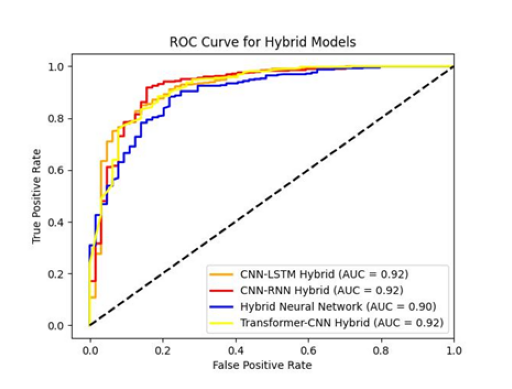

In [ ]:

# Plot ROC curves
for model_name in model_names:
    plt.plot(
        fpr[model_name],
        tpr[model_name],
        lw=2,
        label=f"{model_name} (AUC = {roc_auc[model_name]:.2f})"
    )

# Random baseline
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Formatting
plt.xlim([-0.05, 1.0])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Hybrid Deep Learning Models')
plt.legend(loc="lower right")

# Save + show
plt.savefig('/content/roc_curves.png', dpi=300)
plt.show()

In [ ]:
def prediction_to_raster(clf_names,vrt_file,layers,outputSRS=None,outputBounds=None,width=None,height=None,noData=None):

    for lrn_clf_name in clf_names:
        output_file = "./Output/Figures/" + lrn_clf_name + ".tif"
        gridopt = gdal.GridOptions(format='GTiff',
        zfield=lrn_clf_name,layers=layers,
                        noData=noData,
                        # outputType=gdal.GDT_Int16,
                        outputSRS=outputSRS,
                        outputBounds=outputBounds,
                        width=width,height=height,
                        algorithm='nearest')
        output = gdal.Grid(output_file,vrt_file,options=gridopt)
        # output.FlushCache()
        output = None

        wrap_output_file = "./Output/Figures/" + lrn_clf_name + "_rs.tif"
        wrapopt = gdal.WarpOptions(outputBoundsSRS=outputSRS
                                    # xRes=50,yRes=50,
                                    )
        output = gdal.Warp(wrap_output_file,output_file,
                options=wrapopt
                # outputType=gdal.GDT_Int16,
                # xRes=45, yRes=45
                )
        # output.FlushCache()
        output = None

        # Replace wrapped file by the old one
        Path(output_file).unlink()
        Path(wrap_output_file).rename(output_file)

def extract_rs_unique_values(sampling_shp, raster,raster_names):
    summary = []
    for raster, raster_name in zip(rasters_list, models_names_list):

        src_ds=gdal.Open(raster)
        gt=src_ds.GetGeoTransform()
        rb=src_ds.GetRasterBand(1)

        ds=ogr.Open(sampling_shp)
        lyr=ds.GetLayer()
        summary_raster = []
        for feat in lyr:
            geom = feat.GetGeometryRef()
            mx,my=geom.GetX(), geom.GetY()  #coord in map units

            #Convert from map to pixel coordinates.
            #Only works for geotransforms with no rotation.
            px = int((mx - gt[0]) / gt[1]) #x pixel
            py = int((my - gt[3]) / gt[5]) #y pixel

            intval=rb.ReadAsArray(px,py,1,1)
            if intval is None:
                intval = np.array([[4]])
            # intval=[4 if i is None else i for i in rb.ReadAsArray(px,py,1,1)]
            # print(intval[0]) #intval is a numpy array, length=1 as we only asked for 1 pixel value
            summary_raster.append(intval[0])

        summary_raster = np.row_stack((summary_raster))
        unique_class, unique_count = np.unique(summary_raster,return_counts=True,axis=0)
        unique_count_percentage = (unique_count / np.sum(unique_count,axis=0)) * 100
        model = np.repeat(raster_name,len(unique_class))
        summary.append(np.column_stack((unique_class,unique_count, unique_count_percentage,model)))

    summary = np.row_stack((summary))
    summary = pd.DataFrame(data=summary,columns=["class","count","percentage","model"])
    summary["class"] = summary["class"].astype(str)
    summary["count"] = summary["count"].astype(int)
    summary["percentage"] = summary["percentage"].astype(float)
    summary = summary.round({"percentage":3})

    return summary

In [ ]:
st_data_grid = pd.read_hdf('./Data/Predict/Study_Area45_Array.hdf').iloc[:,0:16]
st_xy_grid = pd.read_hdf('./Data/Predict/Study_Area45_Array.hdf').values[:,-2:]
bins= [0.05,0.30,0.50,0.75,np.inf]
bins_labels=["Very Low", "Low", "Moderate", "High", "Very High"]
bins_labels_replace = {"0":"Very Low", "1":"Low", "2":"Moderate", "3":"High", "4":"Very High",
                        "0.0":"Very Low", "1.0":"Low", "2.0":"Moderate", "3.0":"High", "4.0":"Very High"}
_, prediction_data, prediction_summary = perform_prediction(clf=models_list,clf_names=models_names_list,\
train_data=[X_Data, Y_Data],predict_data=st_data_grid,\
bins=bins,bins_labels=bins_labels,XY=st_xy_grid,export_prediction=False,export_csv=True)
prediction_summary = prediction_summary.replace({"class":bins_labels_replace})

vrt_file = "./Output/Tables/prediction.vrt"
outputBounds,width, height = [305739,4054353,224105,4007733], 1632.68, 932.4
prediction_to_raster(clf_names=models_names_list,vrt_file=vrt_file,
                    layers="prediction",outputSRS="EPSG:32632",
                    outputBounds=outputBounds,width=width,height=height,noData=-9999)
sample_shp = "./Data/shp/GLOF_Pts.shp"
rasters_list = ["./Output/Figures/" + model + ".tif" for model in models_names_list]
prediction_overly_summary = extract_rs_unique_values(sample_shp, rasters_list,models_names_list)
prediction_overly_summary = prediction_overly_summary.replace({"class":bins_labels_replace})


In [ ]:
df = prediction_overly_summary.pivot("model","class","percentage")
df = df.reindex(["Very Low","Low","Moderate","High","Very High"],axis=1)
df.to_csv("./Output/Tables/prediction_overly_summary_data.csv",index=True,header=True)
prediction_overly_summary.to_csv("./Output/Tables/prediction_overly_summary.csv",index=None,header=True)

fig, ax1 = plt.subplots(figsize=(7,7))
bar_width = 0.375
y_pos = np.arange(0,2*len(df),2)
yticks = len(df.columns)*bar_width/2 + y_pos

for i, col in enumerate(df.columns):
    y_pos + i * bar_width
    bars = ax1.barh(y_pos + i * bar_width, df[col],
    height = bar_width,
    label = col)
    for bar in bars:
        # print(bar.get_width())
        ax1.annotate(f"{round(bar.get_width(),2)}%",
                xy=(bar.get_width() + 5,
                    bar.get_y() + bar.get_height()/2
                ),
                ha="center", va='center',
                color=bar.get_facecolor(),size=10,fontweight="medium")
ax1.legend(loc="upper right")
# Add some text for labels, title and custom x-axis tick labels, etc.
ax1.set_xlabel("GLOF Distribution (%)")
ax1.set_ylabel("")
ax1.set_yticks(yticks)
ax1.set_yticklabels(df.index)
ax1.set_ylim(0-bar_width,20)
ax1.set_xlim([-0.05,102.5])
ax1.xaxis.grid(False)
ax1.yaxis.grid(False)
# Save the figure and show
fig.tight_layout()
plt.tight_layout()
fig.savefig("./Output/Figures/GLOF_distr.jpg",dpi=600, quality=100,bbox_inchs="tight")

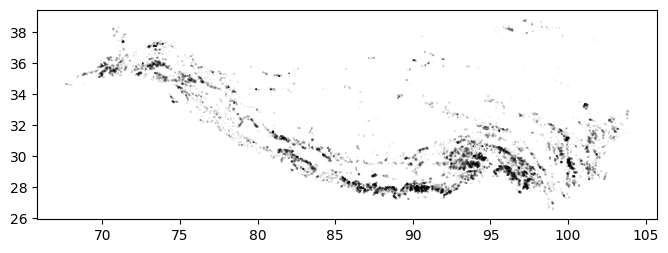

In [ ]:
m_result = rio.open("/content/drive/MyDrive/CNN_LSTM.tif")
m_result_arr = m_result.read(2)
plt.rcParams['figure.figsize'] = [10, 8]
plt.imshow(m_result_arr, cmap="Blacks", vmin=0, vmax=1)

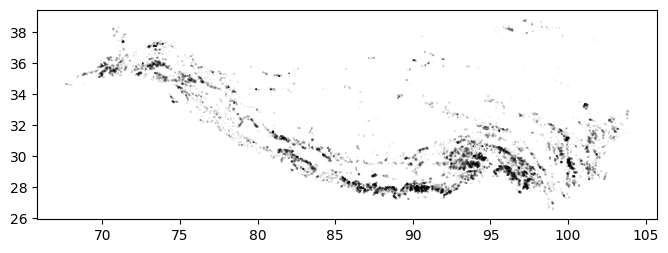

In [ ]:
m_result = rio.open("/content/drive/MyDrive/CNN_RNN.tif")
m_result_arr = m_result.read(2)
plt.rcParams['figure.figsize'] = [10, 8]
plt.imshow(m_result_arr, cmap="Blacks", vmin=0, vmax=1)

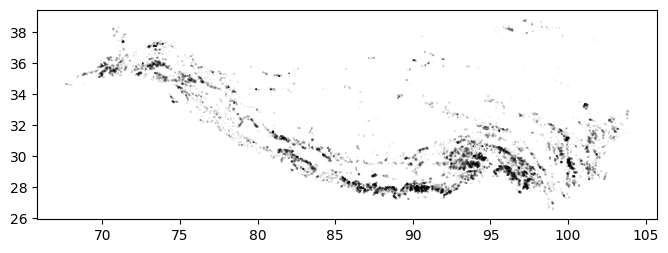

In [ ]:
m_result = rio.open("/content/drive/MyDrive/HNN.tif")
m_result_arr = m_result.read(2)
plt.rcParams['figure.figsize'] = [10, 8]
plt.imshow(m_result_arr, cmap="Blacks", vmin=0, vmax=1)

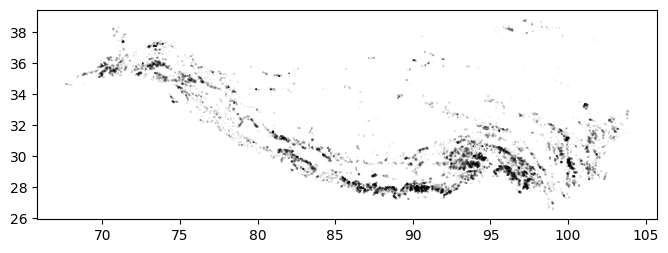

In [ ]:
m_result = rio.open("/content/drive/MyDrive/T-CNN.tif")
m_result_arr = m_result.read(2)
plt.rcParams['figure.figsize'] = [10, 8]
plt.imshow(m_result_arr, cmap="Blacks", vmin=0, vmax=1)

In [ ]:
import numpy as np

def create_probability_raster(lake_df, labeled_array, model_probabilities):
    """
    lake_df: dataframe with lake_id
    labeled_array: raster with connected-component lake IDs
    model_probabilities: probability array aligned with lake_df
    """

    prob_raster = np.zeros_like(labeled_array, dtype=float)

    for i, row in lake_df.iterrows():
        lake_id = int(row["lake_id"])
        prob = model_probabilities[i]
        prob_raster[labeled_array == lake_id] = prob

    return prob_raster

In [ ]:
prob_map_cnn_lstm = create_probability_raster(lake_df, labeled_array, y_prob_cnn_lstm)
prob_map_cnn_rnn = create_probability_raster(lake_df, labeled_array, y_prob_cnn_rnn)
prob_map_transformer = create_probability_raster(lake_df, labeled_array, y_prob_transformer)
prob_map_hnn = create_probability_raster(lake_df, labeled_array, y_prob_hnn)

In [ ]:
import matplotlib.pyplot as plt

def plot_map(prob_map, title):
    plt.figure(figsize=(8,6))
    img = plt.imshow(prob_map, cmap="viridis", vmin=0, vmax=1)
    plt.title(title)
    plt.colorbar(img, label="Susceptibility Probability (0–1)")
    plt.axis("off")
    plt.show()

plot_map(prob_map_cnn_lstm, "CNN-LSTM Susceptibility Map")
plot_map(prob_map_cnn_rnn, "CNN-RNN Susceptibility Map")
plot_map(prob_map_transformer, "Transformer Susceptibility Map")
plot_map(prob_map_hnn, "HNN Susceptibility Map")

In [ ]:
tif_path = "/content/drive/MyDrive/Mydrive/dem_Clip11.tif"   # change path

with rasterio.open(tif_path) as src:
    image = src.read(1)   # read first band
    profile = src.profile
    crs = src.crs
    transform = src.transform

print("CRS:", crs)
print("Shape:", image.shape)

CRS: EPSG:4326
Shape: (28034, 53031)


In [ ]:
!pip install tifffile

In [ ]:
# Load the lake polygons and boundary layer
lakes = gpd.read_file("/content/hkhlakeoutline.shp")  # Provide the path to your lake shapefile
boundary = gpd.read_file("/content/outline.shp")  # Provide the path to your boundary shapefile

In [ ]:
# Assign CRS to both layers (EPSG:32643 is UTM Zone 43N for HKKH region)
lakes = lakes.set_crs('EPSG:32643', allow_override=True)
boundary = boundary.set_crs('EPSG:32643', allow_override=True)


In [ ]:
# Clip lakes within the boundary
lakes_clipped = gpd.overlay(lakes, boundary, how='intersection')

In [ ]:
print(lakes.columns)


Index(['geometry'], dtype='object')


In [ ]:
# Load the CSV file with time-series data
time_series_data = pd.read_csv("/content/updated_glacier_lakes_with_attributes.csv")  # Provide the path to your CSV file

In [ ]:
# Assign a unique identifier to each lake in the clipped lakes GeoDataFrame
lakes_clipped['Lake_ID'] = range(1, len(lakes_clipped) + 1)

In [ ]:
# Now, merge the lakes_clipped GeoDataFrame with the time-series data based on the newly created 'Lake_ID'
lakes_clipped = lakes_clipped.merge(time_series_data, on="Lake_ID", how="left")

In [ ]:
# Check the first few rows and the columns of the clipped lakes shapefile
print(lakes_clipped.head())

# Check the column names to ensure proper attributes for merging or processing
print("Columns in the clipped lakes shapefile:", lakes_clipped.columns)

# Check the geometry type of the shapefile to verify it's correct
print("Geometry type of lakes_clipped:", lakes_clipped.geometry.geom_type.unique())


                                            geometry  Lake_ID  Year  \
0  POLYGON ((97.321 38.819, 97.321 38.819, 97.321...        1  2010   
1  POLYGON ((97.321 38.819, 97.321 38.819, 97.321...        1  2011   
2  POLYGON ((97.321 38.819, 97.321 38.819, 97.321...        1  2012   
3  POLYGON ((97.321 38.819, 97.321 38.819, 97.321...        1  2013   
4  POLYGON ((97.321 38.819, 97.321 38.819, 97.321...        1  2014   

   Lake_Area_km2  Lake_Volume_m3  Proximity_to_Glacier_km  \
0       0.755335    3.952954e+06                 2.115301   
1       0.762888    3.992484e+06                 2.115301   
2       0.770442    4.032013e+06                 2.115301   
3       0.777995    4.071543e+06                 2.115301   
4       0.785548    4.111072e+06                 2.115301   

   Upstream_Watershed_Area_km2  Upstream_Glacier_Area_km2  Slope_deg  \
0                   771.212719                 423.022382  11.916819   
1                  4929.647863                 100.850491  19.

In [ ]:

# Function to calculate Sen's Slope using Theil-Sen Estimator
def calculate_sens_slope(time, values):
    slope, intercept, lower, upper = theilslopes(values, time)
    return slope

In [ ]:
# Function to apply Sen's Slope calculation for each lake's time-series data
def calculate_slope_for_lake(lake_data, feature):
    time = lake_data['Year']
    values = lake_data[feature]
    return calculate_sens_slope(time, values)

In [ ]:
 #Proceed with Sen's Slope calculation for lake volume and lake area (time-series data over years)
lakes_clipped['Sens_Slope_Lake_Volume'] = lakes_clipped.groupby('Lake_ID').apply(lambda x: calculate_slope_for_lake(x, 'Lake_Volume_m3')).reset_index(drop=True)
lakes_clipped['Sens_Slope_Lake_Area'] = lakes_clipped.groupby('Lake_ID').apply(lambda x: calculate_slope_for_lake(x, 'Lake_Area_km2')).reset_index(drop=True)

/tmp/ipython-input-4030343374.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lakes_clipped['Sens_Slope_Lake_Volume'] = lakes_clipped.groupby('Lake_ID').apply(lambda x: calculate_slope_for_lake(x, 'Lake_Volume_m3')).reset_index(drop=True)
/tmp/ipython-input-4030343374.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  lakes_clipped['Sens_Slope_Lake_Area'] = lakes_clipped.groupby('Lake_ID').apply(lambda

In [ ]:
# Save the updated shapefile with Sen's Slope values
lakes_clipped.to_file("updated_lakes_with_sens_slope.shp")  # Provide the output path for the shapefile

/tmp/ipython-input-3146751890.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  lakes_clipped.to_file("updated_lakes_with_sens_slope.shp")  # Provide the output path for the shapefile
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Lake_Area_km2' to 'Lake_Area_'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Lake_Volume_m3' to 'Lake_Volum'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Proximity_to_Glacier_km' to 'Proximity_'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Upstream_Watershed_Area_km2' to 'Upstream_W'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Upstrea

In [ ]:
# Optionally, save the data to CSV
lakes_clipped.to_csv("/content/updated_glacier_lakes_with_attributes.csv", index=False)

In [ ]:
# Check the first few rows to verify
print(lakes_clipped[['Lake_ID', 'Sens_Slope_Lake_Volume', 'Sens_Slope_Lake_Area']].head())

   Lake_ID  Sens_Slope_Lake_Volume  Sens_Slope_Lake_Area
0        1             39529.54009              0.007553
1        1              8836.52289              0.019019
2        1             18564.02291              0.014667
3        1             12427.04092              0.012013
4        1             16479.84884              0.003205


In [ ]:
lakes_clipped = lakes_clipped.rename(columns={'Sens_Slope': 'Sens_Slope_Lake_Volume', 'Sens_Slo_1': 'Sens_Slope_Lake_Area'})

In [ ]:
# Load the updated shapefile with Sen's Slope values
lakes_clipped = gpd.read_file("/content/updated_lakes_with_sens_slope.shp")  # Path to the updated shapefile
# Rename truncated and unclear columns using the provided values
lakes_clipped = lakes_clipped.rename(columns={
    'Lake_Area_': 'Lake_Area_km2',
    'Lake_Volum': 'Lake_Volume_m3',
    'Proximity_': 'Proximity_to_Glacier_km',
    'Upstream_W': 'Upstream_Watershed_Area_km2',
    'Upstream_G': 'Upstream_Glacier_Area_km2',
    'Susceptibi': 'Susceptibility_Score',
    'GLOF_Class': 'GLOF_Class',
    'Topographi': 'Topographic_Potential',
    'Dam_Slope': 'Dam_Slope',
    'Potential_': 'Potential_Flood_Volume_m3',
    'Breach_Vol': 'Breach_Volume_m3',
    'Excess_Vol': 'Excess_Volume_m3',
    'Propagatio': 'Propagation_Probability_Index',
    'Index_of_C': 'Index_of_Connectivity',
    'Glacial_La': 'Glacial_Lake_Area_km2',
    'Glacial__1': 'Glacial_Lake_Volume_m3',
    'Upstream_1': 'Upstream_Glacier_Volume_m3',
    'GLOF_Event': 'GLOF_Event_Location',
    'Sens_Slope': 'Sens_Slope_Lake_Volume',   # For volume
    'Sens_Slo_1': 'Sens_Slope_Lake_Area'     # For area
})

# Check the updated column names to confirm
print(lakes_clipped.columns)

Index(['Lake_ID', 'Year', 'Lake_Area_km2', 'Lake_Volume_m3',
       'Proximity_to_Glacier_km', 'Upstream_Watershed_Area_km2',
       'Upstream_Glacier_Area_km2', 'Slope_deg', 'Susceptibility_Score',
       'GLOF_Class', 'Topographic_Potential', 'Dam_Slope',
       'Potential_Flood_Volume_m3', 'Breach_Volume_m3', 'Excess_Volume_m3',
       'Propagation_Probability_Index', 'Index_of_Connectivity',
       'Glacial_Lake_Area_km2', 'Glacial_Lake_Volume_m3',
       'Upstream_Glacier_Volume_m3', 'GLOF_Event_Location',
       'Sens_Slope_Lake_Volume', 'Sens_Slope_Lake_Area', 'geometry'],
      dtype='object')


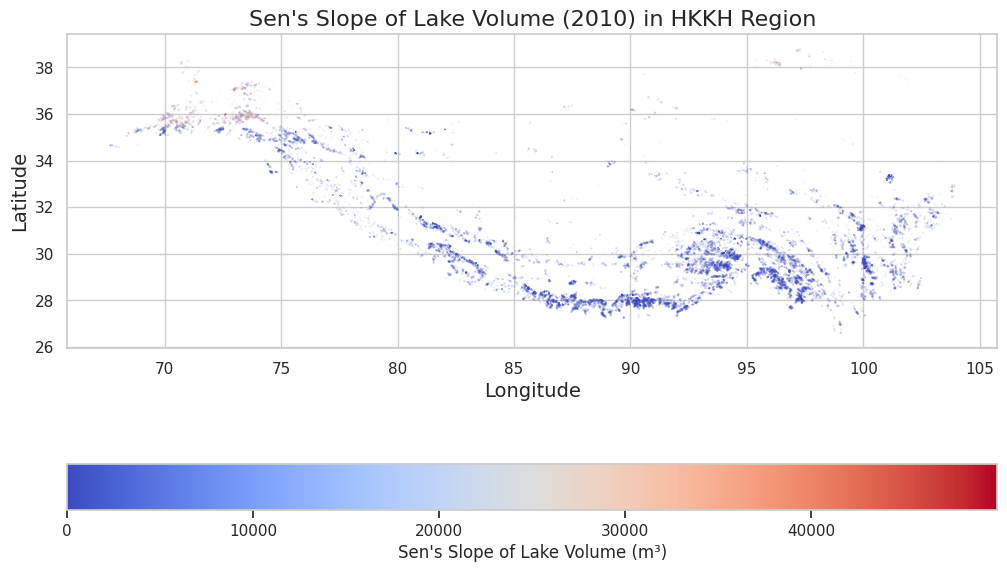

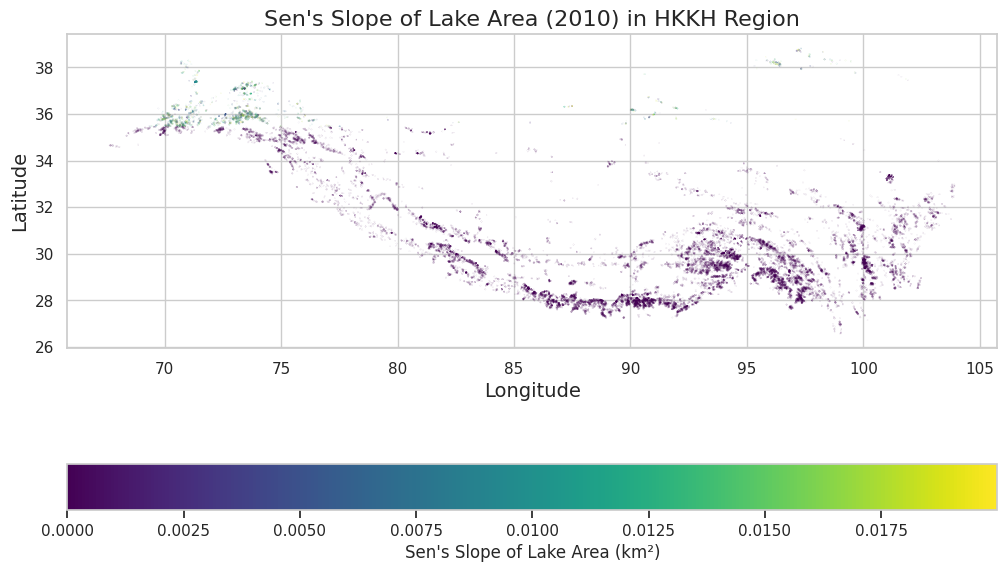

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Ensure 'Sens_Slope_Lake_Volume' and 'Sens_Slope_Lake_Area' columns are numeric and handle NaN values
lakes_clipped['Sens_Slope_Lake_Volume'] = pd.to_numeric(lakes_clipped['Sens_Slope_Lake_Volume'], errors='coerce')
lakes_clipped['Sens_Slope_Lake_Volume'] = lakes_clipped['Sens_Slope_Lake_Volume'].fillna(0)  # Replace NaN values with 0

lakes_clipped['Sens_Slope_Lake_Area'] = pd.to_numeric(lakes_clipped['Sens_Slope_Lake_Area'], errors='coerce')
lakes_clipped['Sens_Slope_Lake_Area'] = lakes_clipped['Sens_Slope_Lake_Area'].fillna(0)  # Replace NaN values with 0

# Filter data for the year 2010
year_data = lakes_clipped[lakes_clipped['Year'] == 2010]

# Set up the plotting environment
sns.set(style="whitegrid")

# -----------------------------------------
# Plotting Sen's Slope of Lake Volume with Colored Edges
# -----------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# Define colormap and normalization for Sen's Slope of Lake Volume
cmap_volume = plt.get_cmap('coolwarm')
norm_volume = mpl.colors.Normalize(vmin=year_data['Sens_Slope_Lake_Volume'].min(), vmax=year_data['Sens_Slope_Lake_Volume'].max())

# Map edgecolor to the Sen's Slope of Lake Volume values using the colormap
edge_colors_volume = year_data['Sens_Slope_Lake_Volume'].apply(lambda x: cmap_volume(norm_volume(x)))

# Plot the data with Sen's Slope of Lake Volume
year_data.plot(column='Sens_Slope_Lake_Volume', ax=ax, cmap=cmap_volume, legend=True,
               legend_kwds={'label': "Sen's Slope of Lake Volume (m³)", 'orientation': "horizontal"},
               edgecolor=edge_colors_volume, linewidth=1, norm=norm_volume)

# Set the title and labels for Sen's Slope of Lake Volume plot
ax.set_title("Sen's Slope of Lake Volume (2010) in HKKH Region", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.grid(True)

# Save the plot for Sen's Slope of Lake Volume
plt.savefig('/content/sens_slope_lake_volume_colored_edges.png', dpi=1200)

# Show the plot for Sen's Slope of Lake Volume
plt.show()

# -----------------------------------------
# Plotting Sen's Slope of Lake Area with Colored Edges
# -----------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# Define colormap and normalization for Sen's Slope of Lake Area
cmap_area = plt.get_cmap('viridis')
norm_area = mpl.colors.Normalize(vmin=year_data['Sens_Slope_Lake_Area'].min(), vmax=year_data['Sens_Slope_Lake_Area'].max())

# Map edgecolor to the Sen's Slope of Lake Area values using the colormap
edge_colors_area = year_data['Sens_Slope_Lake_Area'].apply(lambda x: cmap_area(norm_area(x)))

# Plot the data with Sen's Slope of Lake Area
year_data.plot(column='Sens_Slope_Lake_Area', ax=ax, cmap=cmap_area, legend=True,
               legend_kwds={'label': "Sen's Slope of Lake Area (km²)", 'orientation': "horizontal"},
               edgecolor=edge_colors_area, linewidth=1, norm=norm_area)


# Set the title and labels for Sen's Slope of Lake Area plot
ax.set_title("Sen's Slope of Lake Area (2010) in HKKH Region", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.grid(True)

# Save the plot for Sen's Slope of Lake Area
plt.savefig('/content/sens_slope_lake_area_colored_edges.png', dpi=1200)

# Show the plot for Sen's Slope of Lake Area
plt.show()


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Ensure 'Lake_Volume_m3' and 'Lake_Area_km2' columns are numeric and handle NaN values
lakes_clipped['Lake_Volume_m3'] = pd.to_numeric(lakes_clipped['Lake_Volume_m3'], errors='coerce')
lakes_clipped['Lake_Volume_m3'] = lakes_clipped['Lake_Volume_m3'].fillna(0)  # Replace NaN values with 0

lakes_clipped['Lake_Area_km2'] = pd.to_numeric(lakes_clipped['Lake_Area_km2'], errors='coerce')
lakes_clipped['Lake_Area_km2'] = lakes_clipped['Lake_Area_km2'].fillna(0)  # Replace NaN values with 0

# Filter data for the year 2010
year_data = lakes_clipped[lakes_clipped['Year'] == 2010]

# Set up the plotting environment
sns.set(style="whitegrid")

# -----------------------------------------
# Plotting Lake Volume with Colored Edges
# -----------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# Define colormap and normalization for Lake Volume
cmap_volume = plt.get_cmap('coolwarm')
norm_volume = mpl.colors.Normalize(vmin=year_data['Lake_Volume_m3'].min(), vmax=year_data['Lake_Volume_m3'].max())

# Map edgecolor to the lake volume values using the colormap
edge_colors_volume = year_data['Lake_Volume_m3'].apply(lambda x: cmap_volume(norm_volume(x)))

# Plot the data with lake volume
year_data.plot(column='Lake_Volume_m3', ax=ax, cmap=cmap_volume, legend=True,
               legend_kwds={'label': "Lake Volume (m³)", 'orientation': "horizontal"},
               edgecolor=edge_colors_volume, linewidth=1, norm=norm_volume)

# Add a colorbar for Lake Volume
sm_volume = plt.cm.ScalarMappable(cmap=cmap_volume, norm=norm_volume)
sm_volume.set_array([])  # Empty array for colorbar
plt.colorbar(sm_volume, ax=ax, orientation='horizontal', pad=0.02)

# Set the title and labels for Lake Volume plot
ax.set_title("Spatial Distribution of Lake Volume (2010) in HKKH Region", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.grid(True)

# Save the plot for Lake Volume
plt.savefig('/mnt/data/spatial_distribution_volume_lakes_colored_edges.png', dpi=300)

# Show the plot for Lake Volume
plt.show()

# -----------------------------------------
# Plotting Lake Area with Colored Edges
# -----------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

# Define colormap and normalization for Lake Area
cmap_area = plt.get_cmap('viridis')
norm_area = mpl.colors.Normalize(vmin=year_data['Lake_Area_km2'].min(), vmax=year_data['Lake_Area_km2'].max())

# Map edgecolor to the lake area values using the colormap
edge_colors_area = year_data['Lake_Area_km2'].apply(lambda x: cmap_area(norm_area(x)))

# Plot the data with lake area
year_data.plot(column='Lake_Area_km2', ax=ax, cmap=cmap_area, legend=True,
               legend_kwds={'label': "Lake Area (km²)", 'orientation': "horizontal"},
               edgecolor=edge_colors_area, linewidth=1, norm=norm_area)

# Add a colorbar for Lake Area
sm_area = plt.cm.ScalarMappable(cmap=cmap_area, norm=norm_area)
sm_area.set_array([])  # Empty array for colorbar
plt.colorbar(sm_area, ax=ax, orientation='horizontal', pad=0.02)

# Set the title and labels for Lake Area plot
ax.set_title("Spatial Distribution of Lake Area (2010) in HKKH Region", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.grid(True)

# Save the plot for Lake Area
plt.savefig('/mnt/data/spatial_distribution_area_lakes_colored_edges.png', dpi=300)

# Show the plot for Lake Area
plt.show()


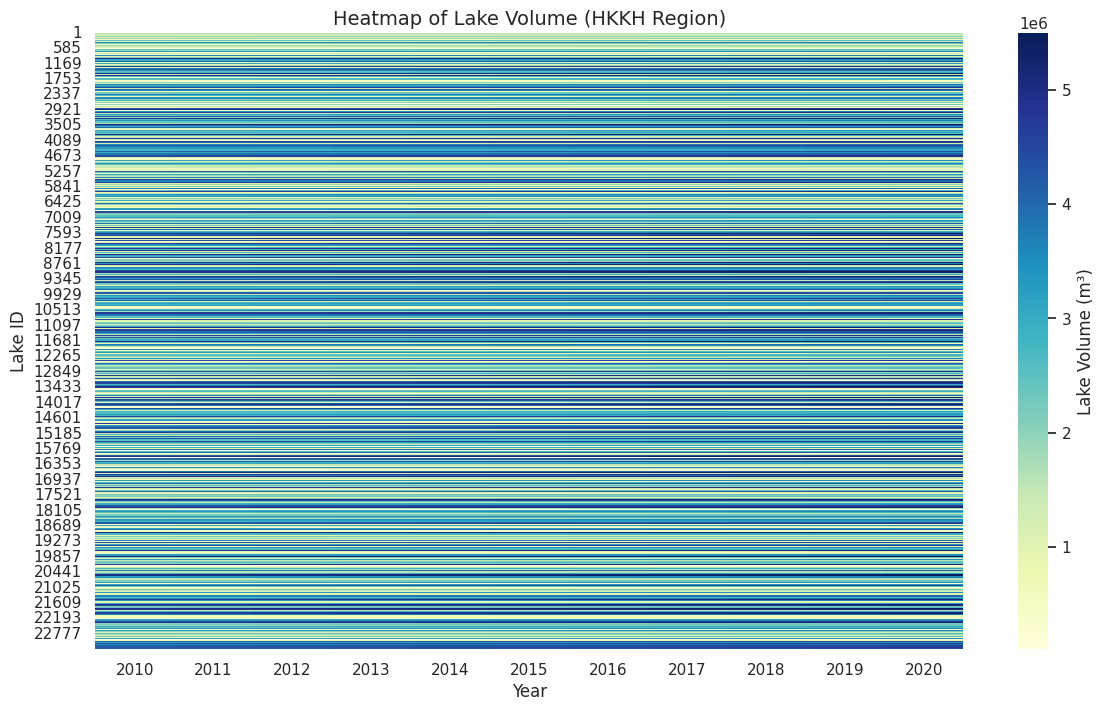

In [ ]:
import seaborn as sns

# Pivot the data for heatmap (rows: Lakes, columns: Years, values: Lake Volume)
heatmap_data = lakes_clipped.pivot_table(values='Lake_Volume_m3', index='Lake_ID', columns='Year')

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Lake Volume (m³)'})

# Title and Labels
plt.title("Heatmap of Lake Volume (HKKH Region)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Lake ID", fontsize=12)
plt.savefig('/content/heatmap_volume.png', dpi=300)
plt.show()


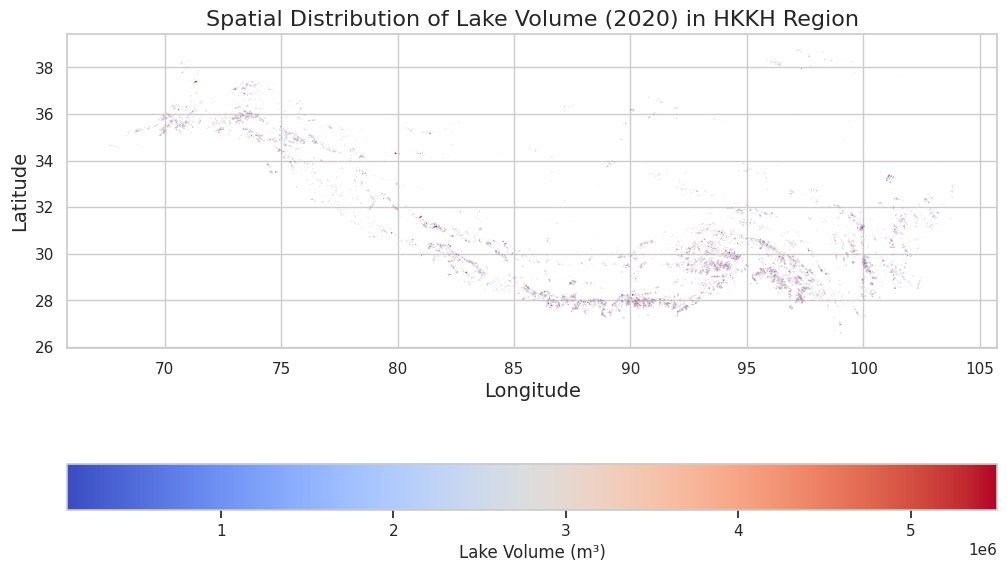

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Ensure that 'Lake_Volume_m3' column is numeric and handle NaN values
lakes_clipped['Lake_Volume_m3'] = pd.to_numeric(lakes_clipped['Lake_Volume_m3'], errors='coerce')
lakes_clipped['Lake_Volume_m3'] = lakes_clipped['Lake_Volume_m3'].fillna(0)

# Filter data for the year 2010
year_data = lakes_clipped[lakes_clipped['Year'] == 2020]

# Create the figure and axis for the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Define the colormap (coolwarm) and normalization based on the lake volume range
cmap = plt.get_cmap('coolwarm')
norm = mpl.colors.Normalize(vmin=year_data['Lake_Volume_m3'].min(), vmax=year_data['Lake_Volume_m3'].max())

# Map edgecolor to the lake volume values using the colormap
edge_colors = year_data['Lake_Volume_m3'].apply(lambda x: cmap(norm(x)))

# Plot the data with lake volume as the column, using the specified colormap and normalization
year_data.plot(column='Lake_Volume_m3', ax=ax, cmap=cmap, legend=True,
               legend_kwds={'label': "Lake Volume (m³)", 'orientation': "horizontal"},
               edgecolor=edge_colors, linewidth=0.5, norm=norm)

# Set the title and labels for the plot
ax.set_title("Spatial Distribution of Lake Volume (2020) in HKKH Region", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)

# Show gridlines for better readability
ax.grid(True)

# Save the plot as an image
plt.savefig('/content/spatial_distribution_volume_lakes_colored_edges.png', dpi=1200)

# Display the plot
plt.show()


/tmp/ipython-input-1158594825.py:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper left', fontsize=12, title='Lake Types')
/tmp/ipython-input-1158594825.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fontsize=12, title='Lake Types')


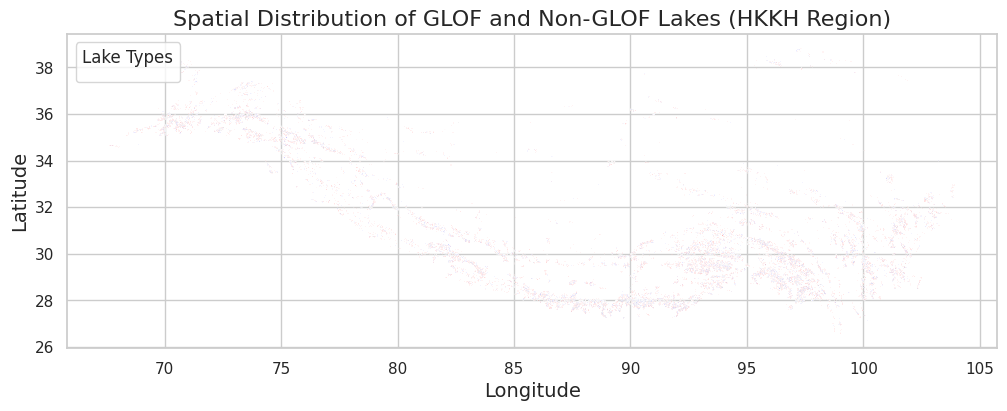

In [ ]:
import matplotlib.pyplot as plt

# Filter data for GLOF-prone (1) and non-GLOF-prone (0) lakes
glof_lakes = lakes_clipped[lakes_clipped['GLOF_Class'] == 1]  # GLOF-prone lakes (GLOF_Class = 1)
non_glof_lakes = lakes_clipped[lakes_clipped['GLOF_Class'] == 0]  # Non-GLOF lakes (GLOF_Class = 0)

# Plot the map
fig, ax = plt.subplots(figsize=(12, 10))

# Plot GLOF-prone lakes in red
glof_lakes.plot(ax=ax, marker='o', color='red', label='GLOF-prone Lakes', markersize=50, alpha=0.7)

# Plot non-GLOF-prone lakes in blue
non_glof_lakes.plot(ax=ax, marker='o', color='blue', label='Non-GLOF-prone Lakes', markersize=50, alpha=0.7)

# Add labels, title, and legend
ax.set_title("Spatial Distribution of GLOF and Non-GLOF Lakes (HKKH Region)", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)

# Add legend with labels for each group
ax.legend(loc='upper left', fontsize=12, title='Lake Types')

# Add gridlines for better readability
ax.grid(True)

# Save the plot as an image
plt.savefig('/content/spatial_distribution_glof_lakes_colored_with_legend.png', dpi=1200)

# Show the map
plt.show()


/tmp/ipython-input-937681558.py:20: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper left')
/tmp/ipython-input-937681558.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left')


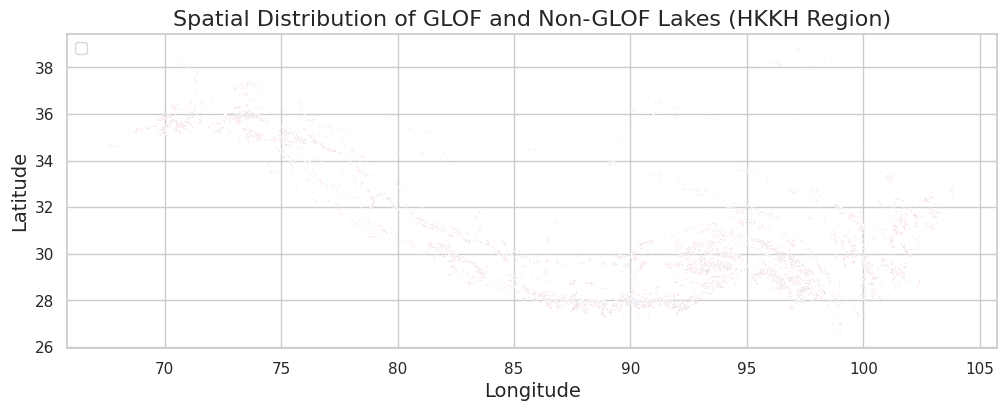

In [ ]:
import matplotlib.pyplot as plt

# Filter data for GLOF-prone (1) and non-GLOF-prone (0) lakes
glof_lakes = lakes_clipped[lakes_clipped['GLOF_Class'] == 1]  # GLOF-prone lakes (GLOF_Class = 1)
non_glof_lakes = lakes_clipped[lakes_clipped['GLOF_Class'] == 0]  # Non-GLOF lakes (GLOF_Class = 0)

# Plot the map
fig, ax = plt.subplots(figsize=(12, 10))

# Plot GLOF-prone lakes in blue
glof_lakes.plot(ax=ax, marker='o', color='red', label='GLOF-prone Lakes', markersize=50, alpha=0.7)

# Plot non-GLOF-prone lakes in red
non_glof_lakes.plot(ax=ax, marker='o', color='blue', label='Non-GLOF-prone Lakes', markersize=50, alpha=0.7)

# Add labels, title, and legend
ax.set_title("Spatial Distribution of GLOF and Non-GLOF Lakes (HKKH Region)", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.legend(loc='upper left')

# Add gridlines for better readability
ax.grid(True)
# Save the plot as an image
plt.savefig('/content/spatial_distribution_glof_lakes_colored.png', dpi=1200)
# Show the map
plt.show()

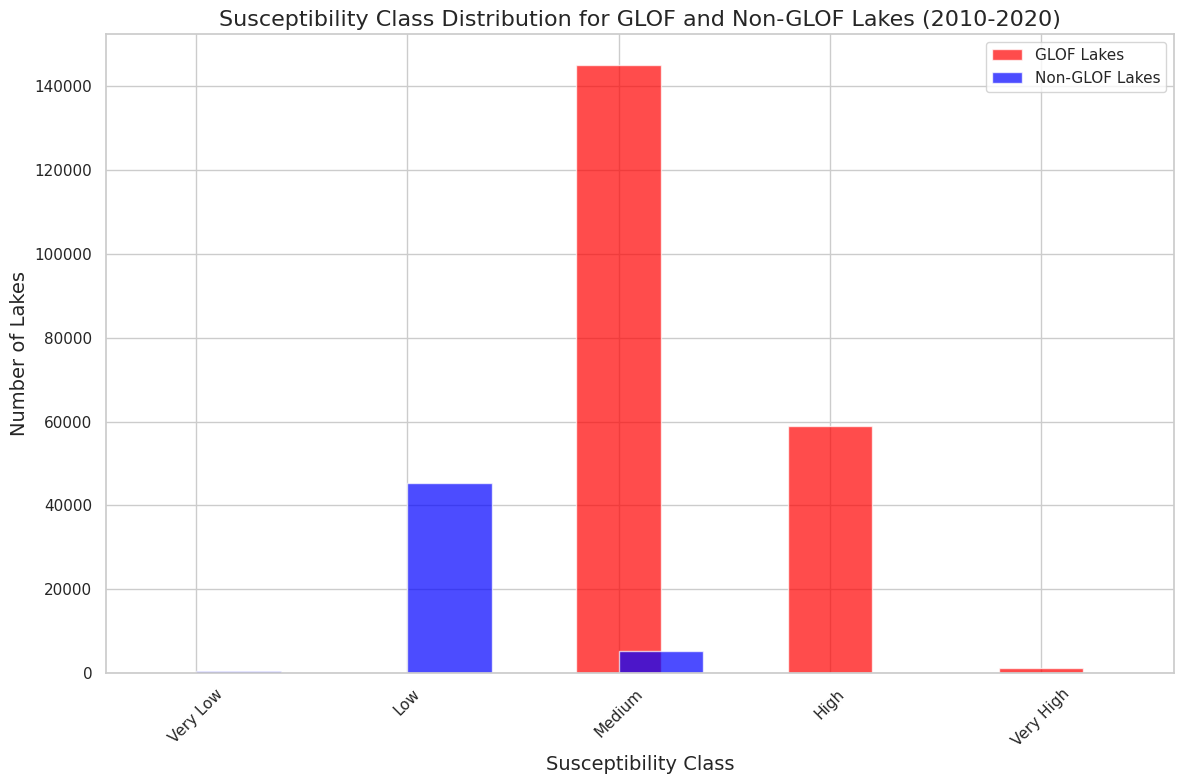

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter data for the years 2010-2020
lake_data_2010_2020 = lakes_clipped[(lakes_clipped['Year'] >= 2010) & (lakes_clipped['Year'] <= 2020)]

# Define the bins for Susceptibility Score
bins = [0, 0.2, 0.4, 0.6, 0.8, 1]  # Adjust these bins based on the range of Susceptibility_Score
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

# Create a new column to categorize Susceptibility_Score
lake_data_2010_2020['Susceptibility_Class'] = pd.cut(lake_data_2010_2020['Susceptibility_Score'], bins=bins, labels=labels)

# Separate GLOF and non-GLOF lakes
glof_lakes_2010_2020 = lake_data_2010_2020[lake_data_2010_2020['GLOF_Class'] == 1]
non_glof_lakes_2010_2020 = lake_data_2010_2020[lake_data_2010_2020['GLOF_Class'] == 0]

# Count the occurrences of each class for GLOF and non-GLOF lakes
glof_counts = glof_lakes_2010_2020['Susceptibility_Class'].value_counts().sort_index()
non_glof_counts = non_glof_lakes_2010_2020['Susceptibility_Class'].value_counts().sort_index()

# Plotting the results
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the bar chart
ax.bar(glof_counts.index, glof_counts.values, width=0.4, label='GLOF Lakes', alpha=0.7, color='red', align='center')
ax.bar(non_glof_counts.index, non_glof_counts.values, width=0.4, label='Non-GLOF Lakes', alpha=0.7, color='blue', align='edge')

# Add labels and title
ax.set_title("Susceptibility Class Distribution for GLOF and Non-GLOF Lakes (2010-2020)", fontsize=16)
ax.set_xlabel("Susceptibility Class", fontsize=14)
ax.set_ylabel("Number of Lakes", fontsize=14)
ax.legend()

# Display gridlines
ax.grid(True)

# Show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/susceptibility_class_distribution_2010_2020.png', dpi=300)
plt.show()


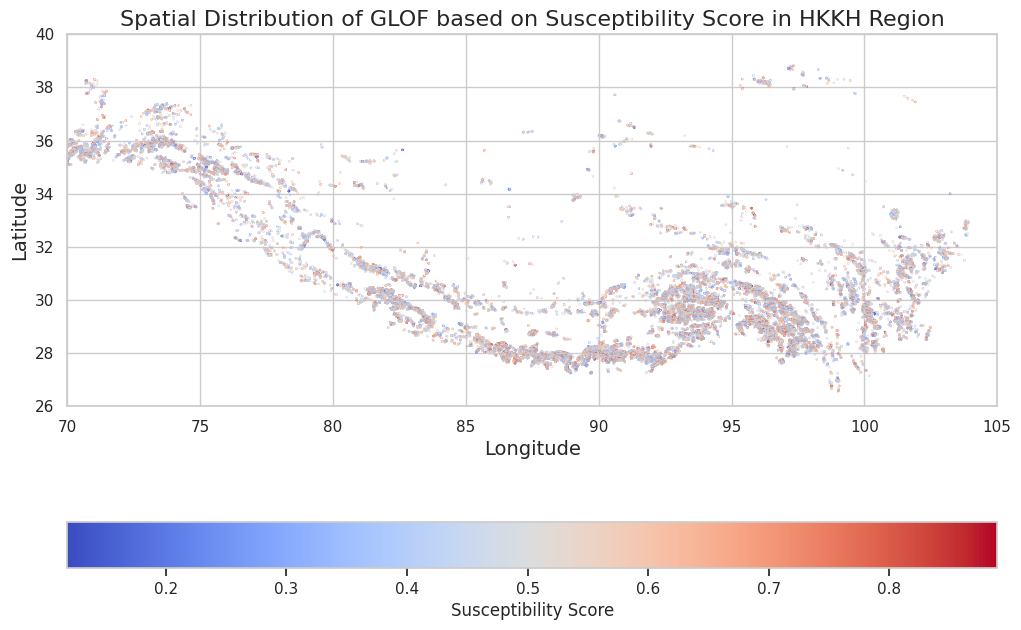

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Ensure that Susceptibility_Score is numeric and handle NaN values
lakes_clipped['Susceptibility_Score'] = pd.to_numeric(lakes_clipped['Susceptibility_Score'], errors='coerce')
lakes_clipped['Susceptibility_Score'] = lakes_clipped['Susceptibility_Score'].fillna(0)

# Set up the plotting environment
plt.figure(figsize=(12, 10))

# Define the colormap for coloring the polygons based on Susceptibility_Score
cmap = plt.get_cmap('coolwarm')
norm = mpl.colors.Normalize(vmin=lakes_clipped['Susceptibility_Score'].min(), vmax=lakes_clipped['Susceptibility_Score'].max())

# Dynamically generate edge colors based on the Susceptibility Score (use a color map)
edge_colors = [cmap(norm(score)) for score in lakes_clipped['Susceptibility_Score']]

# Plot the data with Susceptibility_Score as the column, using the specified colormap and normalization
ax = lakes_clipped.plot(column='Susceptibility_Score', ax=plt.gca(), cmap=cmap, legend=True,
                        legend_kwds={'label': "Susceptibility Score", 'orientation': "horizontal"},
                        edgecolor=edge_colors, linewidth=1.5, norm=norm)

# Set the title and labels
ax.set_title("Spatial Distribution of GLOF based on Susceptibility Score in HKKH Region", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)

# Set the limits for longitude and latitude based on the HKKH region
ax.set_xlim(70, 105)  # Longitude range for HKKH region
ax.set_ylim(26, 40)   # Latitude range for HKKH region

# Add gridlines for better readability
ax.grid(True)

# Save the plot as an image
plt.savefig('/content/spatial_distribution_susceptibility_score_.png', dpi=1200)

# Show the plot
plt.show()


In [ ]:
lakes_clipped = gpd.read_file("/content/updated_lakes_with_sens_slope.shp")

# Print the column names to confirm
print(lakes_clipped.columns)

Index(['Lake_ID', 'Year', 'Lake_Area_', 'Lake_Volum', 'Proximity_',
       'Upstream_W', 'Upstream_G', 'Slope_deg', 'Susceptibi', 'GLOF_Class',
       'Topographi', 'Dam_Slope', 'Potential_', 'Breach_Vol', 'Excess_Vol',
       'Propagatio', 'Index_of_C', 'Glacial_La', 'Glacial__1', 'Upstream_1',
       'GLOF_Event', 'Sens_Slope', 'Sens_Slo_1', 'geometry'],
      dtype='object')


In [ ]:
import geopandas as gpd

# Load the shapefile
lakes_clipped = gpd.read_file("/content/updated_lakes_with_sens_slope.shp")

# Rename 'Lake_Volum' to 'Lake_Volume_m3'
lakes_clipped = lakes_clipped.rename(columns={'Lake_Volum': 'Lake_Volume_m3'})

# Now, let's verify the updated column names
print(lakes_clipped.columns)


Index(['Lake_ID', 'Year', 'Lake_Area_', 'Lake_Volume_m3', 'Proximity_',
       'Upstream_W', 'Upstream_G', 'Slope_deg', 'Susceptibi', 'GLOF_Class',
       'Topographi', 'Dam_Slope', 'Potential_', 'Breach_Vol', 'Excess_Vol',
       'Propagatio', 'Index_of_C', 'Glacial_La', 'Glacial__1', 'Upstream_1',
       'GLOF_Event', 'Sens_Slope', 'Sens_Slo_1', 'geometry'],
      dtype='object')


/tmp/ipython-input-2581810260.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lakes_clipped['Lake_Volume_m3'].fillna(0, inplace=True)
/tmp/ipython-input-2581810260.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

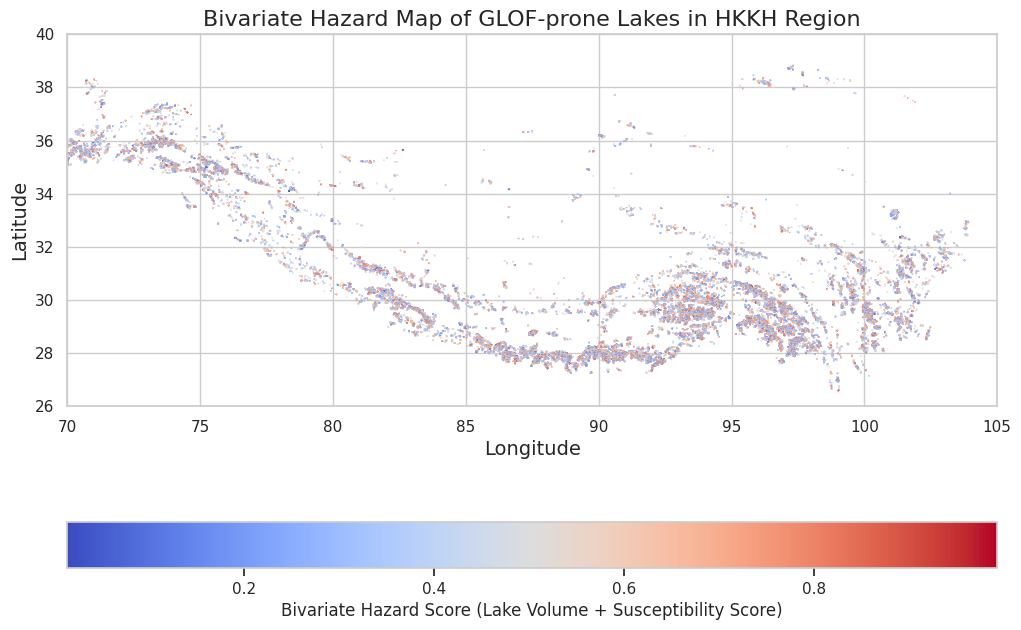

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# Load the shapefile
lakes_clipped = gpd.read_file("/content/updated_lakes_with_sens_slope.shp")

# Rename 'Lake_Volum' to 'Lake_Volume_m3'
lakes_clipped = lakes_clipped.rename(columns={'Lake_Volum': 'Lake_Volume_m3'})

# Ensure numeric values and handle NaN values
lakes_clipped['Lake_Volume_m3'] = pd.to_numeric(lakes_clipped['Lake_Volume_m3'], errors='coerce')
lakes_clipped['Susceptibility_Score'] = pd.to_numeric(lakes_clipped['Susceptibi'], errors='coerce')

# Fill NaN values with 0 or appropriate value (such as neutral color)
lakes_clipped['Lake_Volume_m3'].fillna(0, inplace=True)
lakes_clipped['Susceptibility_Score'].fillna(0, inplace=True)

# Normalize the variables (Lake Volume and Susceptibility Score)
lakes_clipped['Lake_Volume_normalized'] = (lakes_clipped['Lake_Volume_m3'] - lakes_clipped['Lake_Volume_m3'].min()) / (lakes_clipped['Lake_Volume_m3'].max() - lakes_clipped['Lake_Volume_m3'].min())
lakes_clipped['Susceptibility_Score_normalized'] = (lakes_clipped['Susceptibility_Score'] - lakes_clipped['Susceptibility_Score'].min()) / (lakes_clipped['Susceptibility_Score'].max() - lakes_clipped['Susceptibility_Score'].min())

# Create a bivariate hazard score by combining both normalized variables
lakes_clipped['Bivariate_Hazard_Score'] = (lakes_clipped['Lake_Volume_normalized'] * 0.5) + (lakes_clipped['Susceptibility_Score_normalized'] * 0.5)

# Normalize the Bivariate Hazard Score for edge coloring
norm = mpl.colors.Normalize(vmin=lakes_clipped['Bivariate_Hazard_Score'].min(), vmax=lakes_clipped['Bivariate_Hazard_Score'].max())

# Set up the plotting environment
plt.figure(figsize=(12, 10))

# Define the colormap for the bivariate hazard score (use a diverging colormap for clarity)
cmap = plt.get_cmap('coolwarm')

# Plot the spatial distribution of the bivariate hazard score with dynamic edge color
ax = lakes_clipped.plot(column='Bivariate_Hazard_Score', ax=plt.gca(), cmap=cmap, legend=True,
                        legend_kwds={'label': "Bivariate Hazard Score (Lake Volume + Susceptibility Score)", 'orientation': "horizontal"},
                        edgecolor=lakes_clipped['Bivariate_Hazard_Score'].apply(lambda x: cmap(norm(x))),
                        linewidth=1)

# Set the title and labels for the map
ax.set_title("Bivariate Hazard Map of GLOF-prone Lakes in HKKH Region", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)

# Set the limits for longitude and latitude based on the HKKH region
ax.set_xlim(70, 105)  # Longitude range for HKKH region
ax.set_ylim(26, 40)   # Latitude range for HKKH region

# Add gridlines for better readability
ax.grid(True)

# Save the plot as an image
plt.savefig('/content/bivariate_hazard_map_dynamic_edgecolor.png', dpi=1200)

# Show the plot
plt.show()


<Figure size 1200x1000 with 0 Axes>

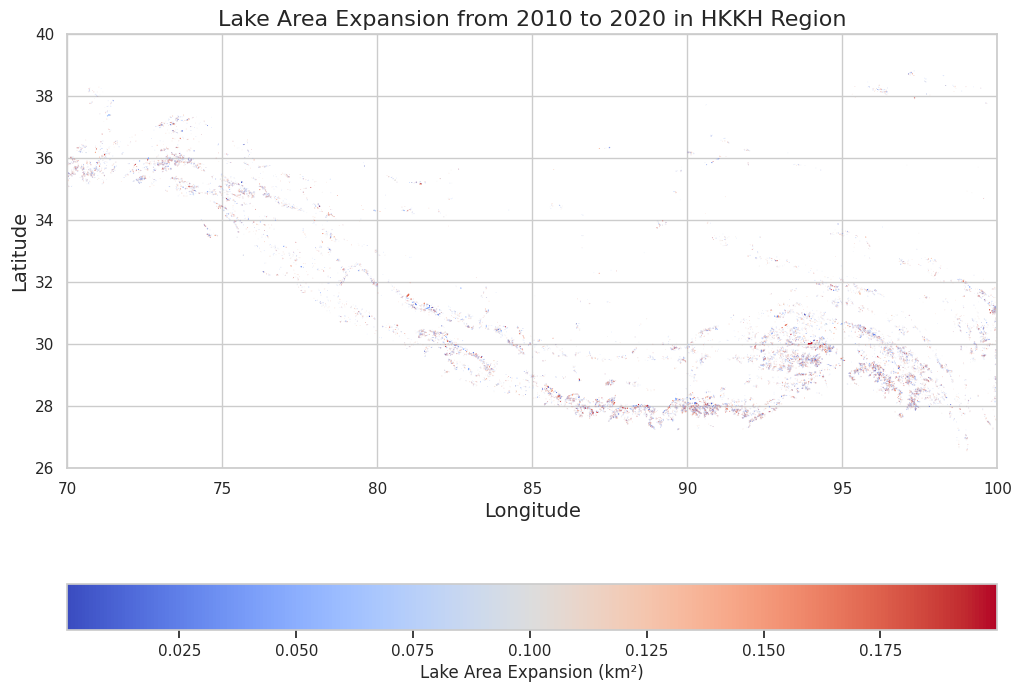

<Figure size 1400x1200 with 0 Axes>

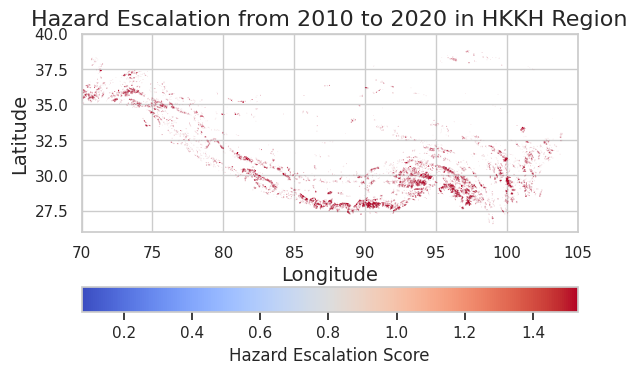

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Load the shapefile (make sure it contains data from 2010 to 2020)
lakes_clipped = gpd.read_file("/content/updated_lakes_with_sens_slope.shp")

# Ensure the necessary columns are numeric and handle NaN values
lakes_clipped['Lake_Area_km2'] = pd.to_numeric(lakes_clipped['Lake_Area_'], errors='coerce')
lakes_clipped['Susceptibility_Score'] = pd.to_numeric(lakes_clipped['Susceptibi'], errors='coerce')
lakes_clipped['Lake_Area_km2'] = lakes_clipped['Lake_Area_km2'].fillna(0)
lakes_clipped['Susceptibility_Score'] = lakes_clipped['Susceptibility_Score'].fillna(0)

# Filter data for 2010 and 2020
lakes_2010 = lakes_clipped[lakes_clipped['Year'] == 2010]
lakes_2020 = lakes_clipped[lakes_clipped['Year'] == 2020]

# Merge the 2010 and 2020 data on Lake_ID to calculate expansion and hazard escalation
merged_data = lakes_2010.set_index('Lake_ID').join(lakes_2020.set_index('Lake_ID'), rsuffix='_2020')

# Calculate Lake Area Expansion (2020 - 2010)
merged_data['Lake_Area_Expansion_km2'] = merged_data['Lake_Area_km2_2020'] - merged_data['Lake_Area_km2']

# Calculate Hazard Escalation: A simple sum of both lake area and susceptibility score
merged_data['Hazard_Escalation_Score'] = (merged_data['Lake_Area_km2_2020'] * 0.5) + (merged_data['Susceptibility_Score_2020'] * 0.5)

# Set up the plotting environment
plt.figure(figsize=(12, 10))

# Create the figure and axis for the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Define the colormap (coolwarm) for the polygons and the edge colors
cmap = plt.get_cmap('coolwarm')
norm = mpl.colors.Normalize(vmin=merged_data['Lake_Area_Expansion_km2'].min(), vmax=merged_data['Lake_Area_Expansion_km2'].max())

# Plot the data with lake area expansion as the column, using the specified colormap and normalization
merged_data.plot(column='Lake_Area_Expansion_km2', ax=ax, cmap=cmap, legend=True,
                 legend_kwds={'label': "Lake Area Expansion (km²)", 'orientation': "horizontal"},
                 edgecolor=merged_data['Lake_Area_Expansion_km2'].apply(lambda x: cmap(norm(x))),
                 linewidth=0.5)

# Set the title and labels
ax.set_title("Lake Area Expansion from 2010 to 2020 in HKKH Region", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)

# Set the limits for longitude and latitude based on the HKKH region
ax.set_xlim(70, 100)  # Longitude range for HKKH region
ax.set_ylim(26, 40)   # Latitude range for better visibility

# Add gridlines for better readability
ax.grid(True)

# Save the plot for lake area expansion
plt.savefig('/content/lake_area_expansion_2010_to_2020_dynamic_edgecolor.png', dpi=1200)

# Show the map for lake area expansion
plt.show()

# Plot the Hazard Escalation map (2020 to 2020) with dynamic color range
plt.figure(figsize=(14, 12))

ax = merged_data.plot(column='Hazard_Escalation_Score',
                      cmap='coolwarm',
                      legend=True,
                      legend_kwds={'label': "Hazard Escalation Score", 'orientation': "horizontal"},
                      edgecolor=merged_data['Hazard_Escalation_Score'].apply(lambda x: cmap(norm(x))),
                      linewidth=0.5)

# Set the title and labels for hazard escalation
ax.set_title("Hazard Escalation from 2010 to 2020 in HKKH Region", fontsize=16)
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)
ax.set_xlim(70, 105)  # Longitude range for HKKH region
ax.set_ylim(26, 40)   # Latitude range for HKKH region

# Add gridlines for better readability
ax.grid(True)

# Save the plot for hazard escalation
plt.savefig('/content/hazard_escalation_2010_to_2020_dynamic_edgecolor.png', dpi=1200)

# Show the map for hazard escalation
plt.show()
